In [44]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

t = 0.000000


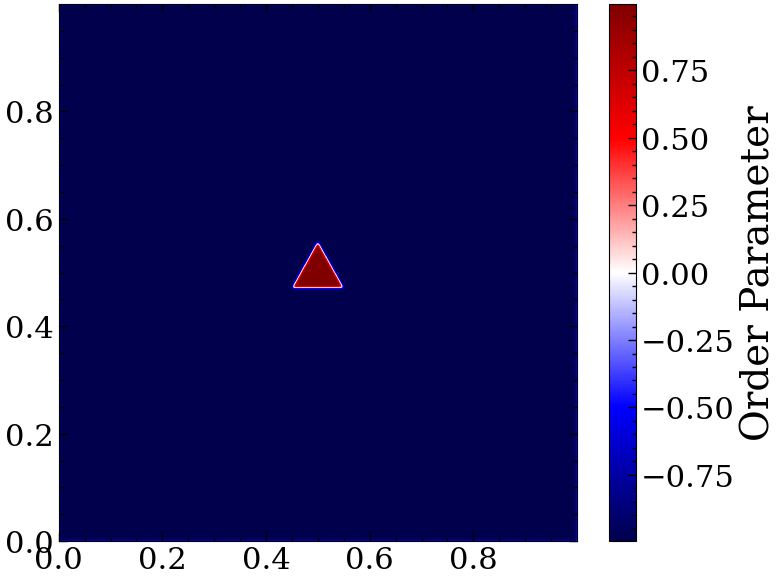

In [60]:
dir = f"../../2D/.saves/26_7_7_1_5_25/"
filename = Path(dir) / 'init.dat'
# Parameters
with open(filename, 'r') as f:
    first_line = f.readline().strip()  # read the first line and remove whitespace
[N, time, dx] = first_line.split(' ')
print(f't = {time}')
# Read the state
data = np.loadtxt(filename, skiprows=1)
x, y, z = data[:,0], data[:,1], data[:,2]
# Meshgrid
nx = len(np.unique(x))
ny = len(np.unique(y))
X = x.reshape(ny, nx)/(float(N)*float(dx))
Y = y.reshape(ny, nx)/(float(N)*float(dx))
Z = z.reshape(ny, nx)   # Slow large

pcm1 = plt.pcolormesh(X, Y, Z, cmap='seismic')   
plt.colorbar(pcm1, label='Order Parameter')

In [46]:
25*25

625

Text(0, 0.5, 'Triangle area')

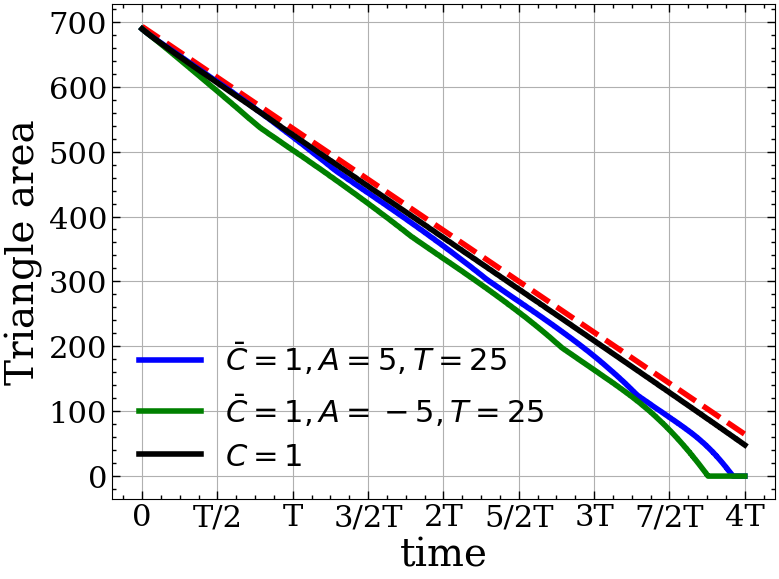

In [59]:
labels=['$\\bar{C}=1, A=5, T=25$', '$\\bar{C}=1, A=-5, T=25$', '$C=1$']
colors=['blue', 'green', 'black']
dirs = [f"../../2D/.saves/26_7_7_1_5_25/", f"../../2D/.saves/26_7_7_1_-5_25/", f"../../2D/.saves/26_7_7_1_0_-1/"]
A0=np.sqrt(3)/4*40*40
tt = np.linspace(0, 100, 1000)
plt.plot(tt, A0-2*np.pi*tt, ls='--',color='red')
for dir in dirs:
    fpath = Path(dir) / "fileTotarea.dat"
    tt, As = np.loadtxt(fpath, unpack=True)
    dx = 0.1
    As = As*dx**2
    plt.plot(tt, As, label=labels[dirs.index(dir)],color=colors[dirs.index(dir)])
plt.grid()
plt.xticks([0,12.5,25,37.5,50,62.5,75,87.5,100],labels=['0','T/2','T','3/2T','2T','5/2T','3T','7/2T','4T'])
#plt.ylim(0, 3*100)
plt.legend()
plt.xlabel('time')
plt.ylabel('Triangle area')



<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3449925/1833621999.py:6: SyntaxWarning: invalid escape sequence '\s'
  labels = ['$C=1+5\sin(2\\pi t/25)$',
/tmp/ipykernel_3449925/1833621999.py:7: SyntaxWarning: invalid escape sequence '\s'
  '$C=1-5\sin(2\\pi t/25)$',
/usr/local/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


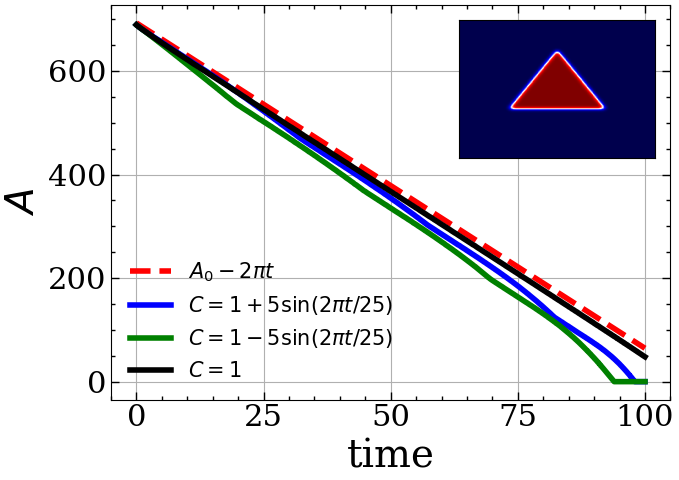

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

labels = ['$C=1+5\sin(2\\pi t/25)$',
          '$C=1-5\sin(2\\pi t/25)$',
          '$C=1$']
colors = ['blue', 'green', 'black']
dirs = [
    "../../2D/.saves/26_7_7_1_5_25/",
    "../../2D/.saves/26_7_7_1_-5_25/",
    "../../2D/.saves/26_7_7_1_0_-1/"
]

fig, ax = plt.subplots(figsize=(7,5))

A0 = np.sqrt(3)/4*40*40
tt = np.linspace(0,100,1000)
ax.plot(tt, A0-2*np.pi*tt, '--', color='red',label='$A_0 - 2\\pi t$')

for lab, col, d in zip(labels, colors, dirs):
    fpath = Path(d) / "fileTotarea.dat"
    tt, As = np.loadtxt(fpath, unpack=True)
    As *= 0.1**2
    ax.plot(tt, As, label=lab, color=col)

ax.grid()
ax.set_xticks(
    [0,25,50,75,100],
    ['0','25','50','75','100']
)
ax.legend(fontsize=15, loc='lower left')
ax.set_xlabel('time')
ax.set_ylabel('$A$')

# ---------------- inset ----------------
axins = inset_axes(ax,
                   width="35%",      # 35% of parent width
                   height="35%",     # 35% of parent height
                   loc='upper right')

# Example data for pcolormesh
pcm = axins.pcolormesh(X, Y, Z, shading='auto', cmap='seismic')

axins.set_xticks([])
axins.set_yticks([])
axins.set_xlim(0.4,0.6)
axins.set_ylim(0.4,0.6)

plt.show()